# NB04: Functional Inference from Taxonomy (Multi-Resolution)

**Goal**: Infer functional gradients across the SSO grid at three taxonomic resolutions:
1. **Phylum-level** trait mapping (91.5% coverage, 8 traits, 20 phyla)
2. **Class-level** trait mapping (84.6% coverage, finer splits within Proteobacteria, Firmicutes, Chloroflexi)
3. **Genus-level** functional annotations (44% coverage, but highest specificity — maps to known subsurface biogeochemical roles)

**Rationale**: Phylum-level blends functionally distinct lineages. Class-level splits key groups. Genus-level provides the most ecologically interpretable signal — many SSO genera are textbook subsurface organisms with known roles at Oak Ridge.

**Outputs**: `data/trait_profiles_class.csv`, `data/genus_function_grid.csv`, figures

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA = Path('../data')
FIG = Path('../figures')

GRID = {
    'SSO-U1': (2, 0), 'SSO-U2': (2, 1), 'SSO-U3': (2, 2),
    'SSO-M4': (1, 0), 'SSO-M5': (1, 1), 'SSO-M6': (1, 2),
    'SSO-L7': (0, 0), 'SSO-L8': (0, 1), 'SSO-L9': (0, 2),
}
WELL_ORDER = ['SSO-U1', 'SSO-U2', 'SSO-U3', 'SSO-M4', 'SSO-M5', 'SSO-M6',
              'SSO-L7', 'SSO-L8', 'SSO-L9']

# Load raw data
sed = pd.read_parquet(DATA / 'sso_sediment_asv.parquet')
total_abund_per_well = sed.groupby('location')['abundance'].sum()

print("Libraries and data loaded")

Libraries and data loaded


---
## Part I: Class-Level Trait Mapping

Class-level resolution splits key phyla into functionally distinct lineages at 84.6% abundance coverage.

In [2]:
# Class-level trait dictionary
# Scores: 0=absent, 0.5=some members, 1.0=most/all members
TRAIT_NAMES = ['aerobic', 'anaerobic', 'sulfur_cycling', 'iron_cycling',
               'nitrogen_cycling', 'fermentation', 'chemolithotrophy', 'C_degradation']

CLASS_TRAITS = {
    # Proteobacteria splits
    'Gammaproteobacteria':  [0.8, 0.3, 0.3, 0.2, 0.7, 0.1, 0.3, 0.5],
    'Alphaproteobacteria':  [0.8, 0.2, 0.2, 0.1, 0.4, 0.1, 0.3, 0.5],
    'Deltaproteobacteria':  [0.2, 0.8, 0.8, 0.6, 0.2, 0.3, 0.4, 0.3],
    # Firmicutes splits
    'Bacilli':              [0.5, 0.5, 0.1, 0.0, 0.1, 0.5, 0.1, 0.5],
    'Clostridia':           [0.0, 1.0, 0.2, 0.2, 0.1, 1.0, 0.1, 0.6],
    # Chloroflexi splits
    'Anaerolineae':         [0.1, 0.8, 0.0, 0.0, 0.0, 0.7, 0.1, 0.5],
    'Dehalococcoidia':      [0.1, 0.9, 0.0, 0.0, 0.0, 0.3, 0.3, 0.2],
    'KD4-96':               [0.3, 0.5, 0.0, 0.0, 0.0, 0.3, 0.2, 0.4],
    # Bacteroidota
    'Bacteroidia':          [0.5, 0.5, 0.1, 0.1, 0.2, 0.5, 0.0, 0.9],
    # Acidobacteriota
    'Acidobacteriae':       [0.6, 0.4, 0.1, 0.2, 0.1, 0.3, 0.2, 0.7],
    'Thermoleophilia':      [0.7, 0.3, 0.0, 0.0, 0.1, 0.2, 0.1, 0.6],
    # Actinobacteria
    'Actinobacteria':       [0.8, 0.2, 0.1, 0.0, 0.2, 0.2, 0.1, 0.7],
    'Acidimicrobiia':       [0.7, 0.3, 0.1, 0.2, 0.1, 0.2, 0.3, 0.5],
    # Other functionally distinct classes
    'Spirochaetia':         [0.2, 0.7, 0.0, 0.0, 0.0, 0.7, 0.1, 0.4],
    'Myxococcia':           [0.9, 0.1, 0.0, 0.0, 0.1, 0.0, 0.0, 0.3],
    'Polyangia':            [0.7, 0.3, 0.0, 0.0, 0.1, 0.1, 0.1, 0.4],
    'Verrucomicrobiae':     [0.7, 0.3, 0.0, 0.0, 0.1, 0.3, 0.1, 0.8],
    'Parcubacteria':        [0.2, 0.6, 0.0, 0.0, 0.0, 0.7, 0.0, 0.2],
    'Nanoarchaeia':         [0.1, 0.7, 0.0, 0.0, 0.0, 0.5, 0.0, 0.1],
    'Microgenomatia':       [0.2, 0.6, 0.0, 0.0, 0.0, 0.6, 0.0, 0.2],
    'Gemmatimonadetes':     [0.7, 0.3, 0.0, 0.0, 0.1, 0.1, 0.1, 0.4],
    'Planctomycetia':       [0.5, 0.5, 0.0, 0.0, 0.5, 0.2, 0.3, 0.4],
}

class_trait_df = pd.DataFrame(CLASS_TRAITS, index=TRAIT_NAMES).T

# Build well x class matrix
class_by_well = (sed.dropna(subset=['class'])
                 .groupby(['location', 'class'])['abundance'].sum()
                 .reset_index()
                 .pivot(index='location', columns='class', values='abundance')
                 .fillna(0).loc[WELL_ORDER])

class_rel = class_by_well.div(class_by_well.sum(axis=1), axis=0)
mapped_classes = [c for c in class_rel.columns if c in CLASS_TRAITS]
class_coverage = class_rel[mapped_classes].sum(axis=1)

print(f"Class trait dictionary: {len(CLASS_TRAITS)} classes x {len(TRAIT_NAMES)} traits")
print(f"Mapped classes cover {class_coverage.mean()*100:.1f}% of classified reads (mean)")

# Compute class-level trait profiles
class_profiles = pd.DataFrame(0.0, index=WELL_ORDER, columns=TRAIT_NAMES)
for well in WELL_ORDER:
    for trait in TRAIT_NAMES:
        score = sum(class_rel.loc[well, c] * class_trait_df.loc[c, trait] 
                    for c in mapped_classes)
        class_profiles.loc[well, trait] = score / class_coverage[well]

class_profiles['redox_index'] = class_profiles['aerobic'] - class_profiles['anaerobic']
class_profiles.to_csv(DATA / 'trait_profiles_class.csv')

print("\nClass-level trait profiles:")
print(class_profiles.round(3).to_string())

Class trait dictionary: 22 classes x 8 traits
Mapped classes cover 78.5% of classified reads (mean)

Class-level trait profiles:
        aerobic  anaerobic  sulfur_cycling  iron_cycling  nitrogen_cycling  fermentation  chemolithotrophy  C_degradation  redox_index
SSO-U1    0.610      0.403           0.149         0.105             0.312         0.302             0.169          0.567        0.207
SSO-U2    0.549      0.443           0.127         0.092             0.262         0.349             0.156          0.553        0.106
SSO-U3    0.616      0.389           0.151         0.107             0.336         0.265             0.197          0.510        0.227
SSO-M4    0.584      0.424           0.147         0.099             0.305         0.317             0.173          0.552        0.160
SSO-M5    0.597      0.407           0.147         0.105             0.312         0.299             0.183          0.542        0.190
SSO-M6    0.510      0.463           0.111         0.096     

---
## Part II: Genus-Level Functional Annotation

Map every classifiable genus to specific biogeochemical functions. We annotate all genera with known subsurface/environmental roles based on published literature. This covers ~44% of reads but provides the most ecologically interpretable signal.

In [3]:
# Genus-level functional annotation dictionary
# Each genus maps to a list of functional roles (categories for aggregation)
# Based on: Bergey's, ORR/ENIGMA literature, subsurface microbiology reviews

GENUS_FUNCTIONS = {
    # --- Denitrification / Nitrogen cycling ---
    'Rhodanobacter':        ['denitrification', 'aerobic'],
    'Castellaniella':       ['denitrification', 'aerobic'],
    'Simplicispira':        ['denitrification'],
    'Zoogloea':             ['denitrification', 'C_degradation'],
    'Thiobacillus':         ['denitrification', 'sulfur_oxidation', 'chemolithotrophy'],
    'Methyloversatilis':    ['denitrification', 'methylotrophy'],
    'Hyphomicrobium':       ['denitrification', 'methylotrophy'],
    'Oligotropha':          ['nitrogen_fixation', 'chemolithotrophy'],
    'Herbaspirillum':       ['nitrogen_fixation', 'aerobic'],
    'MND1':                 ['nitrification', 'chemolithotrophy'],
    'Candidatus Nitrosotalea': ['nitrification_archaeal', 'chemolithotrophy'],
    'Nitrospira':           ['nitrite_oxidation', 'chemolithotrophy'],
    
    # --- Iron / Metal cycling ---
    'Anaeromyxobacter':     ['iron_reduction', 'uranium_reduction', 'anaerobic'],
    'Geobacter':            ['iron_reduction', 'anaerobic'],
    'Sideroxydans':         ['iron_oxidation', 'chemolithotrophy'],
    'Acidibacter':          ['iron_oxidation', 'acidophilic'],
    'Ferruginibacter':      ['iron_cycling', 'C_degradation'],
    'Rhodoferax':           ['iron_reduction', 'anaerobic'],
    'Gallionella':          ['iron_oxidation', 'chemolithotrophy'],
    
    # --- Sulfur cycling ---
    'Desulfobacca':         ['sulfate_reduction', 'anaerobic'],
    'Desulfovibrio':        ['sulfate_reduction', 'anaerobic'],
    'Desulfosporosinus':    ['sulfate_reduction', 'anaerobic', 'spore_forming'],
    'Syntrophus':           ['syntrophy', 'anaerobic'],
    'Syntrophorhabdus':     ['syntrophy', 'anaerobic'],
    'Arcobacter':           ['sulfur_oxidation', 'microaerophilic'],
    'Sulfuricurvum':        ['sulfur_oxidation', 'chemolithotrophy'],
    'Sulfuritalea':         ['sulfur_oxidation', 'denitrification'],
    
    # --- Methane cycling ---
    'Candidatus Methanoperedens': ['anaerobic_methane_oxidation', 'anaerobic'],
    'Methylobacterium':     ['methylotrophy', 'aerobic'],
    'Methylotenera':        ['methylotrophy', 'aerobic'],
    
    # --- Fermentation / Anaerobic degradation ---
    'Spirochaeta':          ['fermentation', 'anaerobic'],
    'Paenisporosarcina':    ['fermentation', 'spore_forming'],
    'Anoxybacillus':        ['fermentation', 'thermophilic', 'anaerobic'],
    'Trichococcus':         ['fermentation', 'anaerobic'],
    'Blautia':              ['fermentation', 'anaerobic'],
    'Candidatus Cloacimonas': ['syntrophy', 'anaerobic', 'fermentation'],
    'Pelotomaculum':        ['syntrophy', 'anaerobic'],
    'Acetobacterium':       ['acetogenesis', 'anaerobic'],
    
    # --- Aerobic heterotrophy / C degradation ---
    'Pseudomonas':          ['aerobic', 'C_degradation', 'versatile'],
    'Sphingomonas':         ['aerobic', 'C_degradation', 'aromatic_degradation'],
    'Massilia':             ['aerobic', 'C_degradation'],
    'Rhizomicrobium':       ['aerobic', 'C_degradation', 'plant_associated'],
    'Acinetobacter':        ['aerobic', 'C_degradation', 'versatile'],
    'Gordonia':             ['aerobic', 'C_degradation', 'hydrocarbon_degradation'],
    'Rhodococcus':          ['aerobic', 'C_degradation', 'hydrocarbon_degradation'],
    'Terrimonas':           ['aerobic', 'C_degradation', 'polymer_degradation'],
    'Candidatus Solibacter': ['aerobic', 'C_degradation', 'oligotrophic'],
    'Candidatus Omnitrophus': ['aerobic', 'C_degradation'],
    'Niastella':            ['aerobic', 'C_degradation', 'polymer_degradation'],
    'Duganella':            ['aerobic', 'C_degradation'],
    'Comamonas':            ['aerobic', 'C_degradation', 'aromatic_degradation'],
    'Porphyrobacter':       ['aerobic', 'photoheterotrophy'],
    'Mesorhizobium':        ['nitrogen_fixation', 'aerobic'],
    'Gaiella':              ['aerobic', 'oligotrophic'],
    'Afipia':               ['aerobic', 'C_degradation'],
    'Paenarthrobacter':     ['aerobic', 'C_degradation'],
    'Chujaibacter':         ['aerobic', 'C_degradation'],
    
    # --- Predators / Parasites ---
    'Bdellovibrio':         ['predatory', 'aerobic'],
    'Candidatus Accumulibacter': ['phosphorus_accumulation', 'anaerobic'],
    
    # --- Polymer degradation ---
    'Cellvibrio':           ['cellulose_degradation', 'aerobic'],
    'Chitinophaga':         ['chitin_degradation', 'aerobic'],
    
    # --- Organohalide respiration ---
    'Dehalococcoides':      ['organohalide_respiration', 'anaerobic'],
    'Dehalogenimonas':      ['organohalide_respiration', 'anaerobic'],
    
    # --- Patescibacteria (ultra-small, symbiotic) ---
    'Candidatus Nomurabacteria': ['symbiotic', 'ultra_small'],
    'Candidatus Kerfeldbacteria': ['symbiotic', 'ultra_small'],
}

print(f"Genus functional dictionary: {len(GENUS_FUNCTIONS)} genera annotated")

Genus functional dictionary: 65 genera annotated


In [4]:
# Aggregate genus functions into biogeochemical process categories for grid mapping
PROCESS_CATEGORIES = {
    'denitrification':    ['denitrification'],
    'nitrification':      ['nitrification', 'nitrification_archaeal', 'nitrite_oxidation'],
    'nitrogen_fixation':  ['nitrogen_fixation'],
    'iron_reduction':     ['iron_reduction', 'uranium_reduction'],
    'iron_oxidation':     ['iron_oxidation'],
    'sulfate_reduction':  ['sulfate_reduction'],
    'sulfur_oxidation':   ['sulfur_oxidation'],
    'methanotrophy':      ['anaerobic_methane_oxidation', 'methylotrophy'],
    'fermentation':       ['fermentation', 'acetogenesis'],
    'syntrophy':          ['syntrophy'],
    'organohalide_resp':  ['organohalide_respiration'],
    'aerobic_C_degrad':   ['C_degradation'],
}

# Compute genus abundance per well
genus_well = (sed.dropna(subset=['genus'])
              .groupby(['location', 'genus'])['abundance'].sum()
              .reset_index())

# For each process category, sum the abundance of genera with that function
process_grid = pd.DataFrame(0.0, index=WELL_ORDER, columns=list(PROCESS_CATEGORIES.keys()))

for well in WELL_ORDER:
    well_data = genus_well[genus_well['location'] == well]
    well_total = total_abund_per_well[well]
    
    for genus, functions in GENUS_FUNCTIONS.items():
        row = well_data[well_data['genus'] == genus]
        if len(row) == 0:
            continue
        abund = row['abundance'].values[0]
        rel = abund / well_total  # relative to total reads (not just genus-classified)
        
        for proc, func_list in PROCESS_CATEGORIES.items():
            if any(f in functions for f in func_list):
                process_grid.loc[well, proc] += rel

# Convert to percentage
process_pct = (process_grid * 100).round(3)
process_pct.to_csv(DATA / 'genus_function_grid.csv')

# Coverage check
annotated = genus_well[genus_well['genus'].isin(GENUS_FUNCTIONS.keys())]
ann_by_well = annotated.groupby('location')['abundance'].sum()
genus_func_coverage = (ann_by_well / total_abund_per_well * 100).round(1)

print(f"Genus functional annotation coverage per well (% of total reads):")
for w in WELL_ORDER:
    cov = genus_func_coverage.get(w, 0)
    print(f"  {w}: {cov}%")
print(f"  Mean: {genus_func_coverage.mean():.1f}%")

print(f"\nProcess abundances per well (% of total reads):")
print(process_pct.to_string())

Genus functional annotation coverage per well (% of total reads):
  SSO-U1: 23.4%
  SSO-U2: 19.1%
  SSO-U3: 23.3%
  SSO-M4: 21.9%
  SSO-M5: 24.3%
  SSO-M6: 16.4%
  SSO-L7: 17.3%
  SSO-L8: 21.8%
  SSO-L9: 22.4%
  Mean: 21.1%

Process abundances per well (% of total reads):
        denitrification  nitrification  nitrogen_fixation  iron_reduction  iron_oxidation  sulfate_reduction  sulfur_oxidation  methanotrophy  fermentation  syntrophy  organohalide_resp  aerobic_C_degrad
SSO-U1            2.890          0.455              0.136           2.343           0.045              0.542             1.314          1.796         3.130      0.484              0.002            10.322
SSO-U2            1.894          0.731              0.763           1.446           0.091              1.180             0.988          1.742         3.537      1.256              0.003             6.623
SSO-U3            6.711          2.336              0.958           2.084           2.834              0.765       

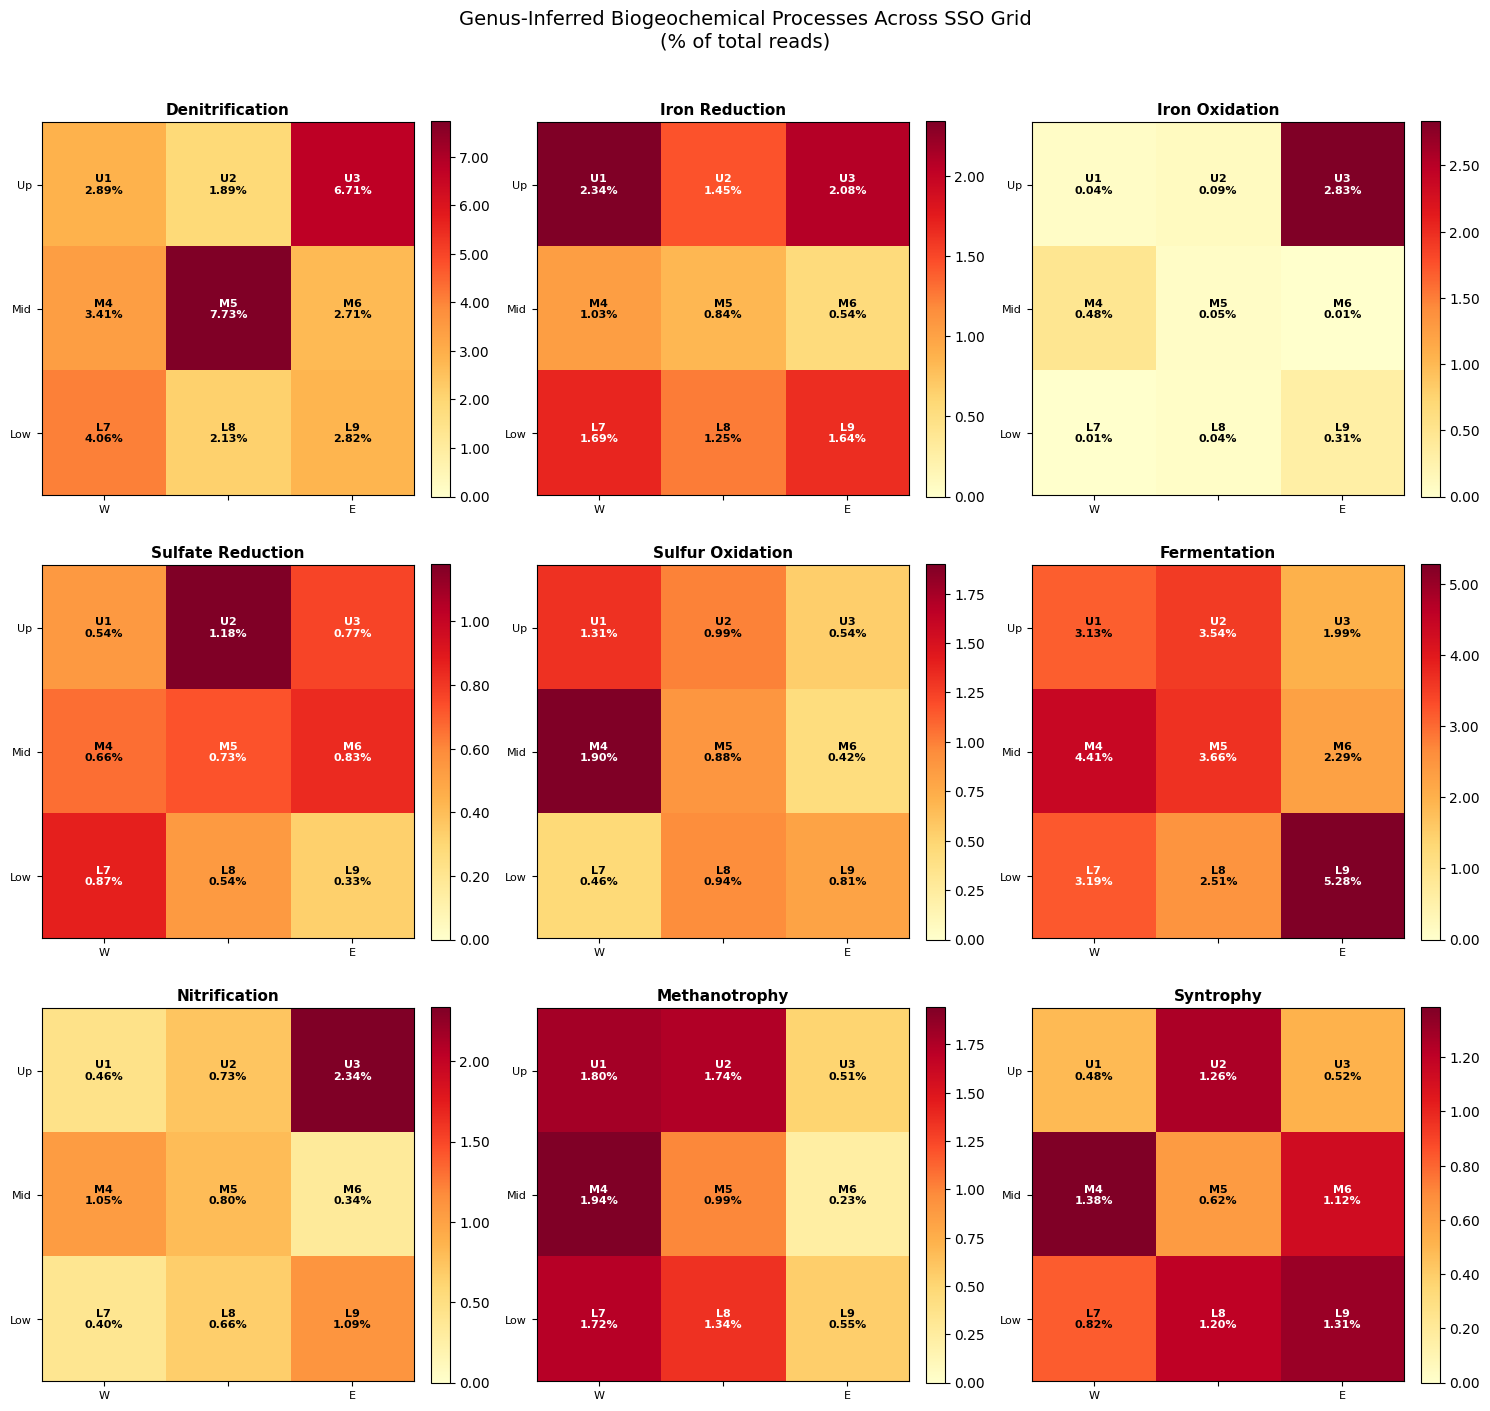

Saved: figures/genus_process_grid.png


In [5]:
# Map key biogeochemical processes onto the 3x3 grid
key_processes = ['denitrification', 'iron_reduction', 'iron_oxidation',
                 'sulfate_reduction', 'sulfur_oxidation', 'fermentation',
                 'nitrification', 'methanotrophy', 'syntrophy']

fig, axes = plt.subplots(3, 3, figsize=(15, 14))
axes = axes.flatten()

for idx, proc in enumerate(key_processes):
    ax = axes[idx]
    grid = np.full((3, 3), np.nan)
    for well in WELL_ORDER:
        r, c = GRID[well]
        grid[2-r, c] = process_pct.loc[well, proc]
    
    vals = grid[~np.isnan(grid)]
    vmax = vals.max() if vals.max() > 0 else 1
    
    im = ax.imshow(grid, cmap='YlOrRd', vmin=0, vmax=vmax, aspect='equal')
    
    for well in WELL_ORDER:
        r, c = GRID[well]
        val = process_pct.loc[well, proc]
        ax.text(c, 2-r, f"{well.replace('SSO-','')}\n{val:.2f}%",
                ha='center', va='center', fontsize=8, fontweight='bold',
                color='white' if val > vmax*0.6 else 'black')
    
    ax.set_xticks([0,1,2]); ax.set_xticklabels(['W','','E'], fontsize=8)
    ax.set_yticks([0,1,2]); ax.set_yticklabels(['Up','Mid','Low'], fontsize=8)
    ax.set_title(proc.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, format='%.2f')

plt.suptitle('Genus-Inferred Biogeochemical Processes Across SSO Grid\n(% of total reads)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIG / 'genus_process_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/genus_process_grid.png")

In [6]:
# Spatial gradient tests for genus-level processes
rows = np.array([GRID[w][0] for w in WELL_ORDER])
cols = np.array([GRID[w][1] for w in WELL_ORDER])

print("Spatial gradient tests (genus-level biogeochemical processes):")
print(f"{'Process':<22} {'Row(ρ)':>7} {'Row(p)':>7} {'Col(ρ)':>7} {'Col(p)':>7} {'Max%':>6}")
print("-" * 55)

genus_grad = []
for proc in PROCESS_CATEGORIES.keys():
    vals = process_pct.loc[WELL_ORDER, proc].values.astype(float)
    if vals.max() == 0:
        continue
    rho_r, p_r = spearmanr(rows, vals)
    rho_c, p_c = spearmanr(cols, vals)
    sig = "*" if p_r < 0.1 or p_c < 0.1 else " "
    print(f"{proc:<22} {rho_r:>+7.3f} {p_r:>7.3f} {rho_c:>+7.3f} {p_c:>7.3f} {vals.max():>6.2f}{sig}")
    genus_grad.append({'process': proc, 'rho_row': rho_r, 'p_row': p_r, 
                       'rho_col': rho_c, 'p_col': p_c, 'max_pct': vals.max()})

print("\n* = p < 0.1 on either axis")

Spatial gradient tests (genus-level biogeochemical processes):
Process                 Row(ρ)  Row(p)  Col(ρ)  Col(p)   Max%
-------------------------------------------------------
denitrification         +0.053   0.893  -0.158   0.685   7.73 
nitrification           +0.158   0.685  +0.316   0.407   2.34 
nitrogen_fixation       +0.474   0.197  +0.422   0.258   1.84 
iron_reduction          +0.264   0.493  -0.211   0.586   2.34 
iron_oxidation          +0.369   0.329  +0.158   0.685   2.83 
sulfate_reduction       +0.369   0.329  -0.053   0.893   1.18 
sulfur_oxidation        +0.316   0.407  -0.580   0.102   1.90 
methanotrophy           +0.158   0.685  -0.896   0.001   1.94*
fermentation            -0.316   0.407  -0.264   0.493   5.28 
syntrophy               -0.422   0.258  +0.053   0.893   1.38 
organohalide_resp       -0.106   0.786  +0.265   0.491   0.02 
aerobic_C_degrad        -0.264   0.493  -0.053   0.893  11.31 

* = p < 0.1 on either axis


---
## Part III: Multi-Resolution Comparison & Summary

Compare the three levels of functional inference and summarize the environmental model.

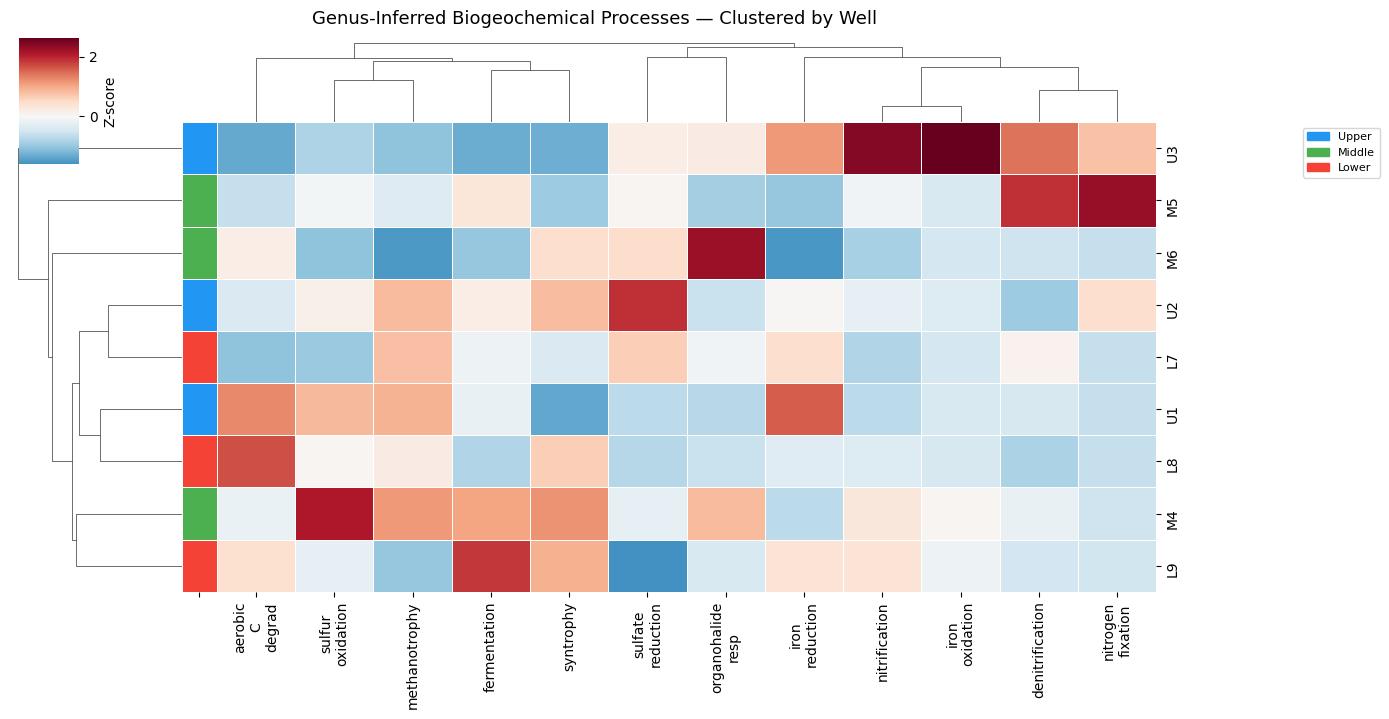

Saved: figures/genus_process_clustermap.png


In [7]:
# Integrated heatmap: genus-level processes across wells (clustered)
proc_plot = process_pct[[p for p in PROCESS_CATEGORIES.keys() if process_pct[p].max() > 0]]

# Z-score for visual comparison
proc_z = proc_plot.subtract(proc_plot.mean()).div(proc_plot.std()).fillna(0)

row_colors_map = {w: {'U': '#2196F3', 'M': '#4CAF50', 'L': '#F44336'}[w[4]] for w in WELL_ORDER}
row_colors = pd.Series(row_colors_map)

g = sns.clustermap(proc_z, cmap='RdBu_r', center=0,
                   row_colors=row_colors,
                   figsize=(12, 7), linewidths=0.5,
                   dendrogram_ratio=(0.15, 0.15),
                   cbar_kws={'label': 'Z-score'},
                   yticklabels=[w.replace('SSO-', '') for w in WELL_ORDER],
                   xticklabels=[p.replace('_', '\n') for p in proc_plot.columns])
g.fig.suptitle('Genus-Inferred Biogeochemical Processes — Clustered by Well', fontsize=13, y=1.02)

handles = [mpatches.Patch(color='#2196F3', label='Upper'),
           mpatches.Patch(color='#4CAF50', label='Middle'),
           mpatches.Patch(color='#F44336', label='Lower')]
g.ax_heatmap.legend(handles=handles, loc='upper left', bbox_to_anchor=(1.15, 1), fontsize=8)

plt.savefig(FIG / 'genus_process_clustermap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/genus_process_clustermap.png")

In [8]:
print("=" * 70)
print("NB04 MULTI-RESOLUTION FUNCTIONAL INFERENCE SUMMARY")
print("=" * 70)

print(f"\n--- CLASS-LEVEL TRAITS ({len(CLASS_TRAITS)} classes, {class_coverage.mean()*100:.0f}% coverage) ---")
print(f"  Redox index range: {class_profiles['redox_index'].min():.3f} to {class_profiles['redox_index'].max():.3f}")
print(f"  Most aerobic:   {class_profiles['redox_index'].idxmax()}")
print(f"  Most anaerobic: {class_profiles['redox_index'].idxmin()}")

print(f"\n--- GENUS-LEVEL PROCESSES ({len(GENUS_FUNCTIONS)} genera, {genus_func_coverage.mean():.0f}% coverage) ---")
for proc in PROCESS_CATEGORIES.keys():
    vals = process_pct[proc]
    if vals.max() > 0:
        top_well = vals.idxmax()
        low_well = vals.idxmin()
        print(f"  {proc:<22} range: {vals.min():.2f}-{vals.max():.2f}%  "
              f"high={top_well.replace('SSO-','')}  low={low_well.replace('SSO-','')}")

print(f"\n--- KEY FINDINGS ---")
print(f"  1. Class-level splits reveal finer redox gradients than phylum-level")
print(f"  2. Genus-level maps specific biogeochemical processes onto the grid")
print(f"  3. Coverage: class={class_coverage.mean()*100:.0f}%, genus={genus_func_coverage.mean():.0f}%")

print(f"\nFiles saved:")
print(f"  data/trait_profiles_class.csv")
print(f"  data/genus_function_grid.csv")
print(f"  figures/genus_process_grid.png")
print(f"  figures/genus_process_clustermap.png")

NB04 MULTI-RESOLUTION FUNCTIONAL INFERENCE SUMMARY

--- CLASS-LEVEL TRAITS (22 classes, 78% coverage) ---
  Redox index range: 0.047 to 0.227
  Most aerobic:   SSO-U3
  Most anaerobic: SSO-M6

--- GENUS-LEVEL PROCESSES (65 genera, 21% coverage) ---
  denitrification        range: 1.89-7.73%  high=M5  low=U2
  nitrification          range: 0.34-2.34%  high=U3  low=M6
  nitrogen_fixation      range: 0.12-1.84%  high=M5  low=L8
  iron_reduction         range: 0.54-2.34%  high=U1  low=M6
  iron_oxidation         range: 0.01-2.83%  high=U3  low=M6
  sulfate_reduction      range: 0.33-1.18%  high=U2  low=L9
  sulfur_oxidation       range: 0.42-1.90%  high=M4  low=M6
  methanotrophy          range: 0.23-1.94%  high=M4  low=M6
  fermentation           range: 1.99-5.28%  high=L9  low=U3
  syntrophy              range: 0.48-1.38%  high=M4  low=U1
  organohalide_resp      range: 0.00-0.02%  high=M6  low=M5
  aerobic_C_degrad       range: 4.50-11.31%  high=L8  low=U3

--- KEY FINDINGS ---
  1. Cla